# EmotionCLIP-ReID RAF-DB Runbook

Notebook này dành riêng cho RAF-DB Basic. Protocol dùng official predefined split của RAF-DB: `train_*` để train và `test_*` để validation/test trong pipeline hiện tại. Không random split.

## 0. Kernel và repo

Chạy cell này trong đúng kernel/environment bạn muốn train.

In [20]:
from pathlib import Path
import os
import sys

REPO = Path.cwd()
if not (REPO / "train_emotionclip.py").exists():
    candidates = [Path("/mnt/e/Source/EmotionCLIP-ReID"), Path.home() / "EmotionCLIP-ReID"]
    for candidate in candidates:
        if (candidate / "train_emotionclip.py").exists():
            REPO = candidate
            os.chdir(REPO)
            break
print("Repo:", REPO)
print("Python:", sys.executable)

Repo: /home/jupyter-hault/EmotionCLIP-ReID
Python: /opt/tljh/user/envs/py310/bin/python


## 1. Kiểm tra package tối thiểu

In [21]:
import importlib.util
import subprocess
import sys

required = ["torch", "PIL", "yaml", "numpy","kaggle"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
print("Missing:", missing)
if missing:
    print("Cài environment theo environment_emotionclip_cuda.yml hoặc cài các package còn thiếu trước khi train.")

# Kaggle chỉ cần nếu bạn muốn tải bằng Kaggle thay vì upload archive RAF-DB sẵn.
print("Kaggle module:", importlib.util.find_spec("kaggle") is not None)

Missing: []
Kaggle module: True


## 2. Process RAF-DB đã có sẵn

Notebook dùng trực tiếp thư mục `data/RAF-DB` hiện có. Cell này chỉ convert `train_labels.csv` và `test_labels.csv` sang `manifest.jsonl` theo predefined RAF-DB Basic protocol. Không tải dữ liệu và không random split.


In [22]:
!git pull

Already up to date.


In [23]:
from pathlib import Path
import subprocess
import sys
REPO = Path.cwd()
RAF_ROOT = REPO / "data" / "RAF-DB"
RAF_MANIFEST = RAF_ROOT / "manifest.jsonl"

if not RAF_ROOT.exists():
    raise FileNotFoundError(f"Không thấy RAF-DB tại {RAF_ROOT}")
for required in ["train_labels.csv", "test_labels.csv"]:
    if not (RAF_ROOT / required).exists():
        raise FileNotFoundError(f"Thiếu {RAF_ROOT / required}")

convert_cmd = [
    sys.executable,
    "tools/convert_rafdb_to_emotion_jsonl.py",
    "--raf-root",
    str(RAF_ROOT),
    "--output",
    str(RAF_MANIFEST),
    "--root-dir",
    str(RAF_ROOT),
]
print("Converting existing data/RAF-DB -> EmotionCLIP manifest")
subprocess.run(convert_cmd, cwd=REPO, check=True)
print("RAF-DB manifest ready:", RAF_MANIFEST)


Converting existing data/RAF-DB -> EmotionCLIP manifest
Wrote 15339 RAF-DB records to /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl
Split protocol: RAF-DB official train/test split; no random split is created.
ROOT_DIR for training: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB
Label files: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/train_labels.csv, /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/test_labels.csv
train: 12271
  anger: 705
  disgust: 717
  fear: 281
  happiness: 4772
  sadness: 1982
  surprise: 1290
  neutral: 2524
val: 3068
  anger: 162
  disgust: 160
  fear: 74
  happiness: 1185
  sadness: 478
  surprise: 329
  neutral: 680
RAF-DB manifest ready: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl


## 3. Kiểm tra manifest và phân bố split

In [24]:
import json
from collections import Counter

assert RAF_MANIFEST.exists(), f"Missing manifest: {RAF_MANIFEST}"
records = [json.loads(line) for line in RAF_MANIFEST.read_text(encoding="utf-8").splitlines() if line.strip()]
print("Total records:", len(records))
print("Split counts:", Counter(record["split"] for record in records))
print("Official split counts:", Counter(record.get("official_split") for record in records))
print("Emotion counts:", Counter(record["emotion"] for record in records))
print("Split protocol:", records[0].get("split_protocol"))
records[:3]

Total records: 15339
Split counts: Counter({'train': 12271, 'val': 3068})
Official split counts: Counter({'train': 12271, 'test': 3068})
Emotion counts: Counter({'happiness': 5957, 'neutral': 3204, 'sadness': 2460, 'surprise': 1619, 'disgust': 877, 'anger': 867, 'fear': 355})
Split protocol: rafdb_official_train_test_no_random_split


[{'image_path': 'DATASET/train/5/train_00001_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00001_aligned.jpg'},
 {'image_path': 'DATASET/train/5/train_00002_aligned.jpg',
  'emotion': 'sadness',
  'emotion_id': 4,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 5,
  'official_split': 'train',
  'official_image_name': 'train_00002_aligned.jpg'},
 {'image_path': 'DATASET/train/4/train_00003_aligned.jpg',
  'emotion': 'happiness',
  'emotion_id': 3,
  'split': 'train',
  'source': 'RAF-DB',
  'split_protocol': 'rafdb_official_train_test_no_random_split',
  'rafdb_label_id': 4,
  'official_split': 'train',
  'official_image_name': 'train_00003_aligned.jpg'}]

### 3.1 Visual phân bố dữ liệu

Cell này vẽ phân bố nhãn theo split để nhìn nhanh imbalance của RAF-DB trước khi train.

Split summary
  train: 12271 images
  val: 3068 images
Emotion summary
  anger: 867
  disgust: 877
  fear: 355
  happiness: 5957
  sadness: 2460
  surprise: 1619
  neutral: 3204


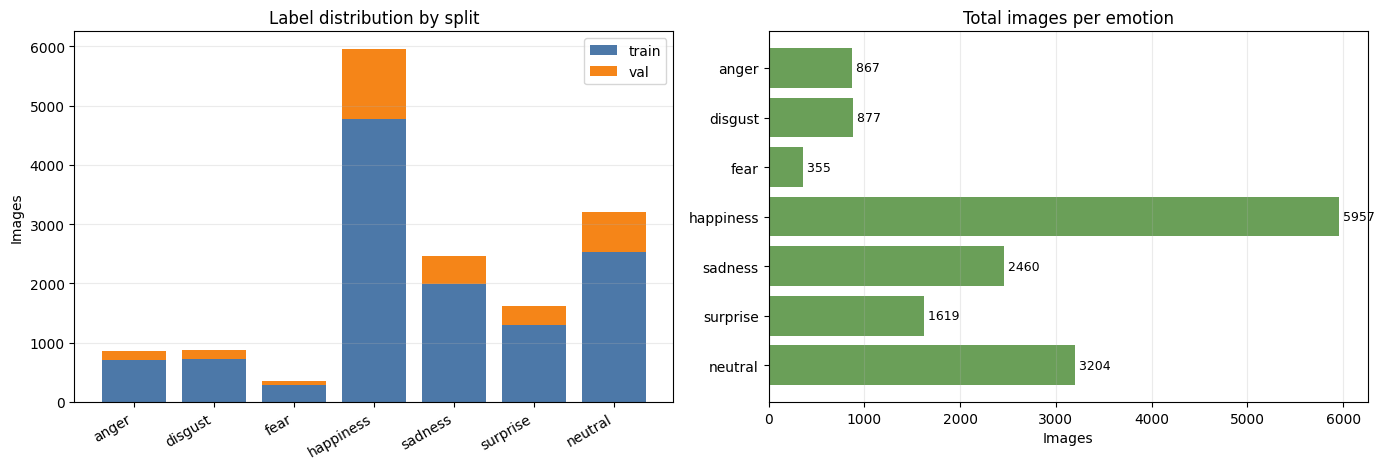

In [25]:
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np

CANONICAL_ORDER = ["anger", "disgust", "fear", "happiness", "sadness", "surprise", "neutral"]
emotion_order = [emotion for emotion in CANONICAL_ORDER if any(record["emotion"] == emotion for record in records)]
emotion_order += sorted({record["emotion"] for record in records} - set(emotion_order))
split_order = [split for split in ["train", "val", "test"] if any(record["split"] == split for record in records)]
split_order += sorted({record["split"] for record in records} - set(split_order))

split_emotion_counts = {
    split: Counter(record["emotion"] for record in records if record["split"] == split)
    for split in split_order
}
total_emotion_counts = Counter(record["emotion"] for record in records)

print("Split summary")
for split in split_order:
    print(f"  {split}: {sum(split_emotion_counts[split].values())} images")
print("Emotion summary")
for emotion in emotion_order:
    print(f"  {emotion}: {total_emotion_counts[emotion]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(emotion_order))
bottom = np.zeros(len(emotion_order), dtype=float)
colors = {"train": "#4c78a8", "val": "#f58518", "test": "#54a24b"}
for split in split_order:
    values = np.array([split_emotion_counts[split][emotion] for emotion in emotion_order], dtype=float)
    axes[0].bar(x, values, bottom=bottom, label=split, color=colors.get(split, None))
    bottom += values
axes[0].set_xticks(x, emotion_order, rotation=30, ha="right")
axes[0].set_ylabel("Images")
axes[0].set_title("Label distribution by split")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

total_values = [total_emotion_counts[emotion] for emotion in emotion_order]
y = np.arange(len(emotion_order))
axes[1].barh(y, total_values, color="#6a9f58")
axes[1].set_yticks(y, emotion_order)
axes[1].invert_yaxis()
axes[1].set_xlabel("Images")
axes[1].set_title("Total images per emotion")
axes[1].grid(axis="x", alpha=0.25)
for idx, value in enumerate(total_values):
    axes[1].text(value, idx, f" {value}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 4. Preview ảnh mẫu

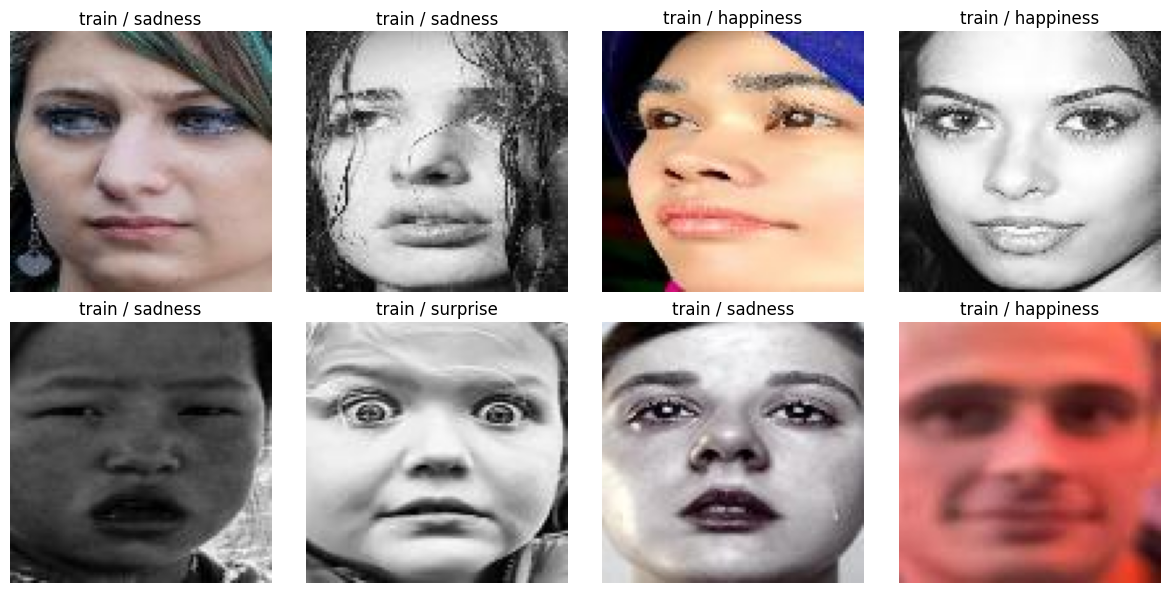

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

sample_records = records[:8]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, record in zip(axes.ravel(), sample_records):
    image_path = RAF_ROOT / record["image_path"]
    ax.imshow(Image.open(image_path).convert("RGB"))
    ax.set_title(f"{record['split']} / {record['emotion']}")
    ax.axis("off")
plt.tight_layout()

### 4.1 Gallery mẫu cân bằng theo lớp

Cell này lấy một ảnh đại diện cho mỗi emotion để kiểm tra nhanh đường dẫn ảnh và nhãn sau khi convert manifest.

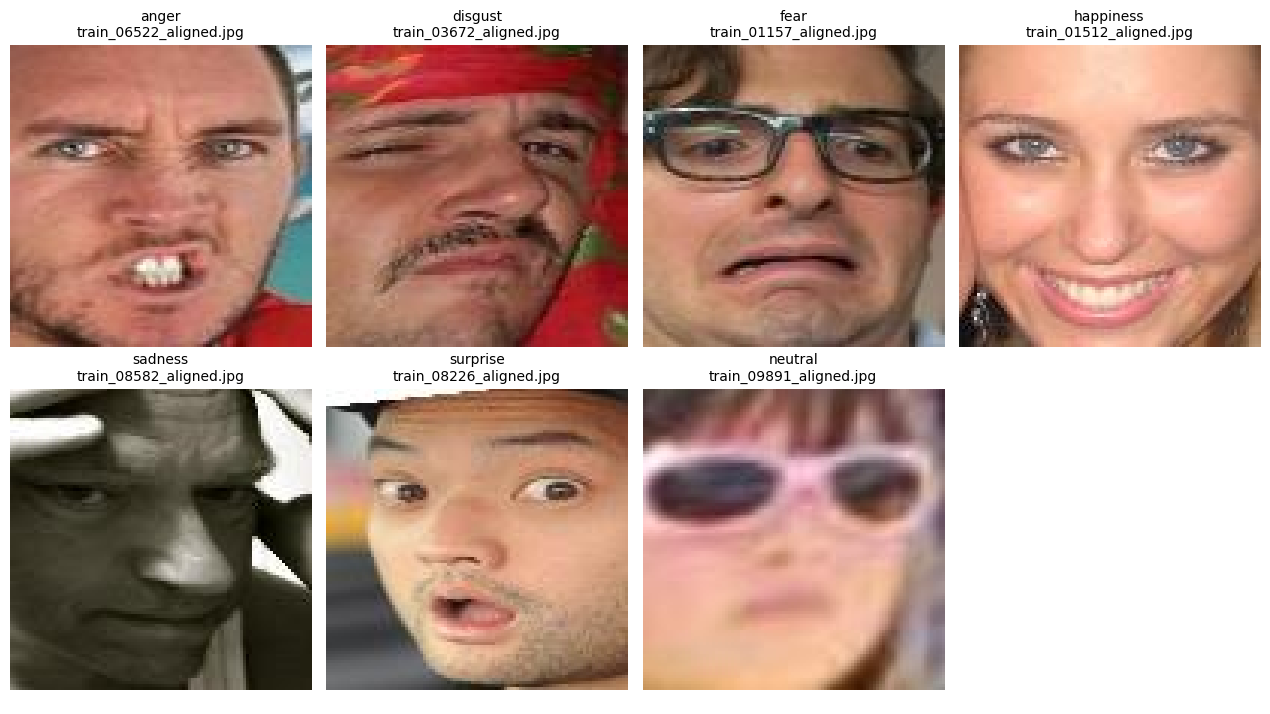

In [27]:
import random
from collections import defaultdict
from pathlib import Path

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

rng = random.Random(1234)
records_by_emotion = defaultdict(list)
for record in records:
    if record["split"] == "train":
        records_by_emotion[record["emotion"]].append(record)

sampled_records = []
for emotion in emotion_order:
    candidates = records_by_emotion.get(emotion, [])
    if candidates:
        sampled_records.append(rng.choice(candidates))

cols = min(4, max(1, len(sampled_records)))
rows = int(np.ceil(len(sampled_records) / cols)) if sampled_records else 1
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.6 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes:
    ax.axis("off")

for ax, record in zip(axes, sampled_records):
    image_path = RAF_ROOT / record["image_path"]
    ax.imshow(Image.open(image_path).convert("RGB"))
    ax.set_title(f"{record['emotion']}\n{Path(record['image_path']).name}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Train RAF-DB

In [28]:
import os
import subprocess
import sys

RAF_CONFIG = REPO / "configs" / "emotion" / "vit_b16_emotionclip_rafdb_quick.yml"
OUTPUT_DIR = REPO / "outputs" / "emotionclip_rafdb_200epochs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
notebook_log = OUTPUT_DIR / "training_notebook_raw.log"
GPU_ID = 1  # doi sang 1 neu muon dung GPU thu hai

train_cmd = [
    sys.executable,
    "-u",
    "train_emotionclip.py",
    "--gpu",
    str(GPU_ID),
    "--no-progress",
    "--config_file",
    str(RAF_CONFIG),
    "DATASETS.MANIFEST",
    str(RAF_MANIFEST),
    "DATASETS.ROOT_DIR",
    str(RAF_ROOT),
    "OUTPUT_DIR",
    str(OUTPUT_DIR),
    "SOLVER.STAGE1.LOG_PERIOD",
    "5",
    "SOLVER.STAGE2.LOG_PERIOD",
    "5",
]

env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"
env["EMOTIONCLIP_PROGRESS"] = "0"
print("Running:", " ".join(train_cmd), flush=True)
print("Notebook log:", notebook_log, flush=True)

process = subprocess.Popen(
    train_cmd,
    cwd=REPO,
    env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

with notebook_log.open("w", encoding="utf-8") as log_handle:
    for line in process.stdout:
        print(line, end="", flush=True)
        log_handle.write(line)
        log_handle.flush()

return_code = process.wait()
if return_code != 0:
    raise subprocess.CalledProcessError(return_code, train_cmd)


Running: /opt/tljh/user/envs/py310/bin/python -u train_emotionclip.py --gpu 1 --no-progress --config_file /home/jupyter-hault/EmotionCLIP-ReID/configs/emotion/vit_b16_emotionclip_rafdb_quick.yml DATASETS.MANIFEST /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl DATASETS.ROOT_DIR /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB OUTPUT_DIR /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_rafdb_quick SOLVER.STAGE1.LOG_PERIOD 5 SOLVER.STAGE2.LOG_PERIOD 5
Notebook log: /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_rafdb_quick/training_notebook_raw.log
2026-07-04 19:11:06,762 emotionclip.train INFO: CUDA device selected device=cuda:1 name=Tesla T4 visible_devices=2
2026-07-04 19:11:06,762 emotionclip.train INFO: Run config config_file=/home/jupyter-hault/EmotionCLIP-ReID/configs/emotion/vit_b16_emotionclip_rafdb_quick.yml device=cuda:1 model=ViT-B-16 manifest=/home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/manifest.jsonl root_dir=/home/jupyter-hault/Emotion

## 6. Xem metrics tốt nhất hoặc epoch mới nhất

In [ ]:
from utils.notebook_metrics import load_validation_metrics, print_validation_summary

validation_metrics = load_validation_metrics(
    candidate_output_dirs=[
        OUTPUT_DIR,
        REPO / "outputs" / "emotionclip_rafdb_quick",
        REPO / "outputs" / "RAF-DB",
    ],
)

RESULT_DIR = validation_metrics["result_dir"]
metric_files = validation_metrics["metric_files"]
metric_history = validation_metrics["metric_history"]
metrics_by_epoch = validation_metrics["metrics_by_epoch"]
metrics_latest = validation_metrics["metrics_latest"]
metrics_best = validation_metrics["metrics_best"]
best_metric = validation_metrics["best_metric"]

print_validation_summary(validation_metrics)

### 6.1 Biểu đồ metric validation theo epoch

Cell này gom `metrics_epoch_*.json` thành training dynamics của validation/test split.

In [ ]:
from utils.notebook_metrics import plot_validation_metric_curves

plot_validation_metric_curves(validation_metrics, dataset_name="RAF-DB", file_prefix="rafdb")

### 6.2 Biểu đồ loss/accuracy training từ log

Cell này parse `train.log` hoặc `training_notebook_raw.log`. Nếu notebook chưa có log train RAF-DB, nó dùng CSV report đã extract sẵn nếu có.

In [ ]:
from utils.notebook_metrics import load_training_history, plot_training_metric_curves, unique_paths

training_candidate_dirs = unique_paths(
    RESULT_DIR,
    OUTPUT_DIR,
    REPO / "outputs" / "RAF-DB",
    REPO / "outputs" / "emotionclip_rafdb_quick",
    REPO / "outputs" / "report_w4",
)
training_history, training_source = load_training_history(
    training_candidate_dirs,
    csv_candidates=[
        RESULT_DIR / "training_epoch_losses.csv",
        OUTPUT_DIR / "training_epoch_losses.csv",
        REPO / "outputs" / "report_w4" / "rafdb_training_history_extracted.csv",
    ],
)
plot_training_metric_curves(training_history, training_source, RESULT_DIR, file_prefix="rafdb")

### 6.3 Confusion matrix và per-class F1

Cell này dùng epoch mới nhất đang được chọn trong `metrics_latest`. Chạy lại cell metrics phía trên nếu muốn đổi thư mục/epoch.

In [ ]:
from utils.notebook_metrics import plot_confusion_matrix_and_f1

plot_confusion_matrix_and_f1(validation_metrics, dataset_name="RAF-DB", file_prefix="rafdb")

## 7. Infer một ảnh validation

Ground truth: sadness
Image: /home/jupyter-hault/EmotionCLIP-ReID/data/RAF-DB/DATASET/test/5/test_0001_aligned.jpg
Weight: /home/jupyter-hault/EmotionCLIP-ReID/outputs/emotionclip_rafdb_quick/best_emotionclip.pth
/home/jupyter-hault/EmotionCLIP-ReID/processor/processor_emotionclip.py:155: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=

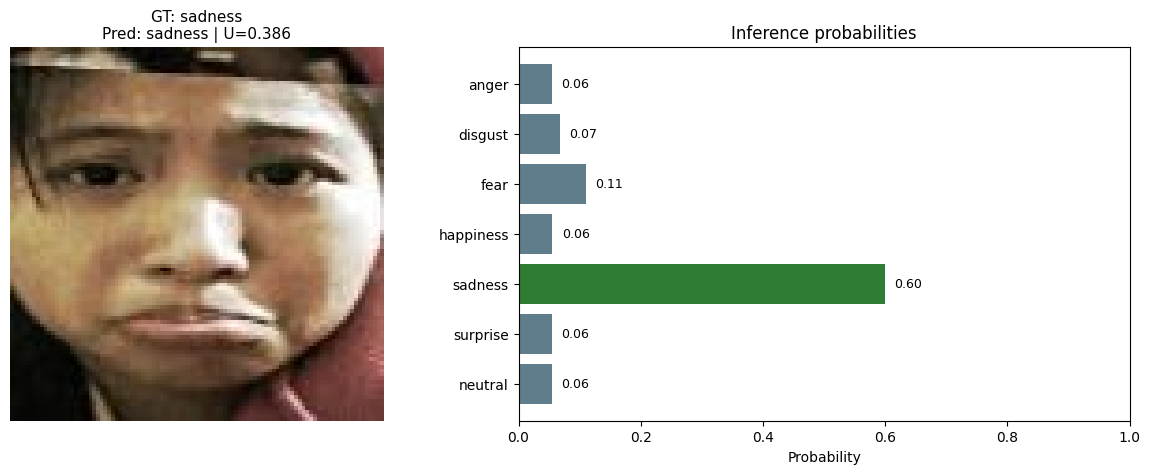

In [38]:
import json
import subprocess
import sys

from PIL import Image
import matplotlib.pyplot as plt

result_dir = globals().get("RESULT_DIR", OUTPUT_DIR)
eval_records = [record for record in records if record["split"] in {"val", "test"}]
if not eval_records:
    eval_records = records

sample = eval_records[0]
weight_candidates = [
    result_dir / "best_emotionclip.pth",
    OUTPUT_DIR / "best_emotionclip.pth",
    REPO / "outputs" / "RAF-DB" / "best_emotionclip.pth",
]
weight = next((path for path in weight_candidates if path.exists()), weight_candidates[0])
image_path = RAF_ROOT / sample["image_path"]

print("Ground truth:", sample["emotion"])
print("Image:", image_path)
print("Weight:", weight)

if not weight.exists():
    print("Chưa thấy best_emotionclip.pth; hãy chạy train hoặc trỏ weight đúng trước khi infer.")
else:
    completed = subprocess.run(
        [
            sys.executable,
            "infer_emotionclip.py",
            "--config_file",
            str(RAF_CONFIG),
            "--weight",
            str(weight),
            "--image",
            str(image_path),
        ],
        cwd=REPO,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        check=True,
    )
    print(completed.stdout)
    json_start = completed.stdout.find("{")
    result = json.loads(completed.stdout[json_start:]) if json_start >= 0 else {}
    probabilities = result.get("probabilities", {})
    names = list(probabilities.keys())
    values = [probabilities[name] for name in names]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.0, 1.35]})
    axes[0].imshow(Image.open(image_path).convert("RGB"))
    axes[0].set_title(
        f"GT: {sample['emotion']}\nPred: {result.get('emotion')} | U={result.get('uncertainty', 0):.3f}",
        fontsize=11,
    )
    axes[0].axis("off")

    y = range(len(names))
    colors = ["#2e7d32" if name == result.get("emotion") else "#607d8b" for name in names]
    axes[1].barh(y, values, color=colors)
    axes[1].set_yticks(list(y), names)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Probability")
    axes[1].set_title("Inference probabilities")
    axes[1].invert_yaxis()
    for idx, value in enumerate(values):
        axes[1].text(min(value + 0.015, 0.98), idx, f"{value:.2f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
